## **Introduction:**

Breast cancer is one of the most common and well-studied cancers worldwide, yet it remains a leading cause of cancer-related mortality among women. Early and accurate diagnosis — distinguishing malignant from benign tumors — is critical for improving patient outcomes. At the same time, emerging research suggests that metabolic factors such as elevated blood glucose, BMI, and insulin resistance may play a role in cancer risk beyond the tumor's physical characteristics.

To explore this issue in more detail, we analyze two publicly available breast cancer datasets: the Wisconsin Breast Cancer Dataset, which characterizes tumors using cell-nucleus measurements (radius, perimeter, area, texture, etc.), and the Breast Cancer Coimbra Dataset, which records metabolic and demographic markers (glucose, BMI, age, insulin, etc.) for cancer patients and healthy controls. The methods we plan to use include descriptive statistics, data visualization, feature engineering, and grouped analysis.

This analysis will help address the question: *Which measurable features — tumor morphology or patient metabolic health — are most strongly associated with breast cancer diagnosis?* Understanding these relationships could help clinicians and researchers identify the most informative screening markers and guide future predictive modeling efforts.

## **Libraries:**

These are the libraries used in this analysis and the reasons they are necessary:

- **NumPy:** to manipulate data and make calculations efficiently using multi-dimensional arrays
- **Pandas:** to clean, transform, and analyze datasets using Series and DataFrames
- **Matplotlib:** to enhance control of plot elements when creating data visualizations
- **Seaborn:** to create aesthetically pleasing and informative data visualizations
- **warnings:** to filter out warning messages and provide a cleaner notebook layout

**Import Python libraries:**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("darkgrid")
import warnings
warnings.filterwarnings('ignore')

## **Data Description:**

<u>**Dataset 1 — Wisconsin Breast Cancer Dataset:**</u>

**Source:** [https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data](https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data)

**Original Purpose:** To predict whether a breast tumor is malignant or benign based on features computed from a digitized image of a fine needle aspirate (FNA) of a breast mass.

**When Collected:** October 31, 1995 — University of Wisconsin, Madison.

**Number of Variables in Original:** 32 (id, diagnosis, and 30 numeric feature columns representing mean, standard error, and worst values of 10 cell nucleus measurements).

**Peculiarities:** Contains one fully empty column (`Unnamed: 32`) introduced during CSV export. The `diagnosis` column is stored as an object (`M` = malignant, `B` = benign) and must be cast to a categorical dtype. No other missing values are present.

| Variable Name | Description | Data Type |
| :-- | :-- | :-- |
| id | Unique patient ID | int64 |
| diagnosis | Tumor diagnosis: M (malignant) or B (benign) | object → category |
| radius_mean | Mean of distances from center to points on the perimeter | float64 |
| texture_mean | Standard deviation of grey-scale values | float64 |
| perimeter_mean | Mean perimeter of the tumor | float64 |
| area_mean | Mean area of the tumor | float64 |
| smoothness_mean | Mean local variation in radius lengths | float64 |
| compactness_mean | Mean of perimeter² / area - 1.0 | float64 |
| concavity_mean | Mean severity of concave portions of the contour | float64 |
| concave_points_mean | Mean number of concave portions of the contour | float64 |
| symmetry_mean | Mean symmetry of the tumor | float64 |
| fractal_dimension_mean | Mean "coastline approximation" − 1 | float64 |
| *(+ SE and worst versions of each above feature)* | | float64 |

<u>**Dataset 2 — Breast Cancer Coimbra Dataset:**</u>

**Source:** [https://www.kaggle.com/datasets/yasserhessein/breast-cancer-coimbra-data-set](https://www.kaggle.com/datasets/yasserhessein/breast-cancer-coimbra-data-set)

**Original Purpose:** To develop predictive models for the early diagnosis of breast cancer using routine blood analysis markers — a less invasive and more accessible alternative to imaging.

**When Collected:** Between 2009 and 2013 at the University Hospital Centre of Coimbra, Portugal.

**Number of Variables in Original:** 10 (9 predictor features + 1 binary classification target).

**Peculiarities:** The `Classification` column uses integer encoding (1 = healthy controls, 2 = cancer patients) rather than string labels, so it must be mapped before analysis. No missing values are present. The dataset is relatively small (116 observations), which limits the statistical power of subgroup analyses.

| Variable Name | Description | Data Type |
| :-- | :-- | :-- |
| Age | Patient age in years | int64 |
| BMI | Body mass index (kg/m²) | float64 |
| Glucose | Blood glucose level (mg/dL) | float64 |
| Insulin | Blood insulin level (µU/mL) | float64 |
| HOMA | Homeostasis model assessment of insulin resistance | float64 |
| Leptin | Leptin level (ng/mL) | float64 |
| Adiponectin | Adiponectin level (µg/mL) | float64 |
| Resistin | Resistin level (ng/mL) | float64 |
| MCP.1 | Monocyte chemoattractant protein-1 level (pg/dL) | float64 |
| Classification | 1 = Healthy control, 2 = Cancer patient | int64 → category |

## **Import / Prepare Data:**

Two datasets were imported: the Wisconsin Breast Cancer Dataset (`data.csv`) and the Breast Cancer Coimbra Dataset (`dataR2.csv`). After importing, the following cleaning steps were applied to each dataset:

1. Check the number of rows and columns
2. Check for missing values
3. Check for duplicate rows
4. Inspect and fix data types as needed
5. Standardize column names to snake_case
6. Standardize categorical string values
7. Concatenate both cleaned datasets into a single combined DataFrame for analysis

### Import Wisconsin Breast Cancer Dataset:

In [2]:
Wcancer = pd.read_csv('data.csv')
Wcancer.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


**Check the number of rows and columns:**

In [3]:
Wcancer.shape

(569, 33)

**Check for missing values:**

In [4]:
Wcancer.isna().sum()[Wcancer.isna().sum() > 0]

Unnamed: 32    569
dtype: int64

**Check for duplicate rows:**

In [5]:
Wcancer.duplicated().sum()

np.int64(0)

**Inspect data types and fix as needed:**

The `Unnamed: 32` column is entirely empty (an artifact of the CSV export) and is dropped. The `diagnosis` column is stored as `object` but represents a binary category, so it is cast to `category`. The `id` column is an identifier and is dropped as it carries no analytical value.

In [6]:
Wcancer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [7]:
# Drop the empty trailing column and the non-informative ID column
Wcancer = Wcancer.drop(columns=['id', 'Unnamed: 32'], errors='ignore')

# Cast diagnosis to category
Wcancer['diagnosis'] = Wcancer['diagnosis'].astype('category')

Wcancer.dtypes

diagnosis                  category
radius_mean                 float64
texture_mean                float64
perimeter_mean              float64
area_mean                   float64
smoothness_mean             float64
compactness_mean            float64
concavity_mean              float64
concave points_mean         float64
symmetry_mean               float64
fractal_dimension_mean      float64
radius_se                   float64
texture_se                  float64
perimeter_se                float64
area_se                     float64
smoothness_se               float64
compactness_se              float64
concavity_se                float64
concave points_se           float64
symmetry_se                 float64
fractal_dimension_se        float64
radius_worst                float64
texture_worst               float64
perimeter_worst             float64
area_worst                  float64
smoothness_worst            float64
compactness_worst           float64
concavity_worst             

**Standardize column names to snake_case:**

In [8]:
Wcancer.columns = Wcancer.columns.str.lower().str.replace(' ', '_')
print(Wcancer.columns.tolist())

['diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave_points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave_points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave_points_worst', 'symmetry_worst', 'fractal_dimension_worst']


**Standardize string values in the diagnosis column:**

In [9]:
Wcancer['diagnosis'] = Wcancer['diagnosis'].str.strip().str.lower()
print(Wcancer['diagnosis'].value_counts())

diagnosis
b    357
m    212
Name: count, dtype: int64


**Add a dataset label column and save the cleaned file:**

In [10]:
Wcancer['dataset'] = 'wisconsin'
Wcancer.to_csv('Cleaned_Wisconsin_Cancer.csv', index=False)
print("Wisconsin dataset cleaned and saved.")

Wisconsin dataset cleaned and saved.


### Import Breast Cancer Coimbra Dataset:

In [11]:
df_coimbra = pd.read_csv('dataR2.csv')
df_coimbra.head()

,Age,BMI,Glucose,Insulin,HOMA,Leptin,Adiponectin,Resistin,MCP.1,Classification
0,48,23.500000,70,2.707,0.467409,8.8071,9.702400,7.99585,417.114,1
1,83,20.690495,92,3.115,0.706897,8.8438,5.429285,4.06405,468.786,1
2,82,23.124670,91,4.498,1.009651,17.9393,22.432040,9.27715,554.697,1
3,68,21.367521,77,3.226,0.612725,9.8827,7.169560,12.76600,928.220,1
4,86,21.111111,92,3.549,0.805386,6.6994,4.819240,10.57635,773.920,1


**Check the number of rows and columns:**

In [12]:
df_coimbra.shape

(116, 10)

**Check for missing values:**

In [13]:
df_coimbra.isna().sum()[df_coimbra.isna().sum() > 0]

Series([], dtype: int64)

**Check for duplicate rows:**

In [14]:
df_coimbra.duplicated().sum()

np.int64(0)

**Inspect data types and fix as needed:**

The `Classification` column uses integer encoding (1 = healthy control, 2 = cancer patient). It will be remapped to descriptive string labels and cast to `category` for clarity in all downstream visualizations.

In [15]:
df_coimbra.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 116 entries, 0 to 115
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             116 non-null    int64  
 1   BMI             116 non-null    float64
 2   Glucose         116 non-null    int64  
 3   Insulin         116 non-null    float64
 4   HOMA            116 non-null    float64
 5   Leptin          116 non-null    float64
 6   Adiponectin     116 non-null    float64
 7   Resistin        116 non-null    float64
 8   MCP.1           116 non-null    float64
 9   Classification  116 non-null    int64  
dtypes: float64(7), int64(3)
memory usage: 9.2 KB


In [16]:
# Remap classification integers to meaningful labels
df_coimbra['Classification'] = df_coimbra['Classification'].map({1: 'healthy', 2: 'cancer'})
df_coimbra['Classification'] = df_coimbra['Classification'].astype('category')

df_coimbra.dtypes

Age                  int64
BMI                float64
Glucose              int64
Insulin            float64
HOMA               float64
Leptin             float64
Adiponectin        float64
Resistin           float64
MCP.1              float64
Classification    category
dtype: object

**Standardize column names to snake_case:**

In [17]:
df_coimbra.columns = df_coimbra.columns.str.lower().str.replace('.', '_', regex=False).str.replace(' ', '_')
print(df_coimbra.columns.tolist())

['age', 'bmi', 'glucose', 'insulin', 'homa', 'leptin', 'adiponectin', 'resistin', 'mcp_1', 'classification']


**Add a dataset label column and save the cleaned file:**

In [18]:
df_coimbra['dataset'] = 'coimbra'
df_coimbra.to_csv('Cleaned_Coimbra_Cancer.csv', index=False)
print("Coimbra dataset cleaned and saved.")

Coimbra dataset cleaned and saved.


### Combine Both Cleaned Datasets:

The two datasets do not share the same column schema — the Wisconsin data focuses on tumor morphology while the Coimbra data captures metabolic markers. Because there is no shared join key, they are combined with an **outer concatenation**, which preserves all columns from both datasets. Rows from each source will have NaN values for columns that exist only in the other dataset. A `dataset` column tracks the provenance of each row.

In [19]:
combined = pd.concat([Wcancer, df_coimbra], join='outer', ignore_index=True)
print("Combined shape:", combined.shape)
combined.head()

Combined shape: (685, 42)


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,...,age,bmi,glucose,insulin,homa,leptin,adiponectin,resistin,mcp_1,classification
0,m,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,m,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,m,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,m,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,m,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Final Inspection of the Combined Dataset:

After concatenation, the combined DataFrame contains rows from both sources. Columns unique to one dataset will appear as NaN for rows from the other — this is expected and acceptable since the two datasets measure fundamentally different features.

In [20]:
pd.set_option('display.max_columns', None)
combined.head(10)

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave_points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst,dataset,age,bmi,glucose,insulin,homa,leptin,adiponectin,resistin,mcp_1,classification
0,m,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,wisconsin,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,m,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,wisconsin,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,m,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,wisconsin,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,m,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,wisconsin,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,m,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,wisconsin,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,m,12.45,15.70,82.57,477.1,0.12780,0.17000,0.15780,0.08089,0.2087,0.07613,0.3345,0.8902,2.217,27.19,0.007510,0.03345,0.03672,0.01137,0.02165,0.005082,15.47,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.1741,0.3985,0.12440,wisconsin,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,m,18.25,19.98,119.60,1040.0,0.09463,0.10900,0.11270,0.07400,0.1794,0.05742,0.4467,0.7732,3.180,53.91,0.004314,0.01382,0.02254,0.01039,0.01369,0.002179,22.88,27.66,153.20,1606.0,0.1442,0.2576,0.3784,0.1932,0.3063,0.08368,wisconsin,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,m,13.71,20.83,90.20,577.9,0.11890,0.16450,0.09366,0.05985,0.2196,0.07451,0.5835,1.3770,3.856,50.96,0.008805,0.03029,0.02488,0.01448,0.01486,0.005412,17.06,28.14,110.60,897.0,0.1654,0.3682,0.2678,0.1556,0.3196,0.11510,wisconsin,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,m,13.00,21.82,87.50,519.8,0.12730,0.19320,0.18590,0.09353,0.2350,0.07389,0.3063,1.0020,2.406,24.32,0.005731,0.03502,0.03553,0.01226,0.02143,0.003749,15.49,30.73,106.20,739.3,0.1703,0.5401,0.5390,0.2060,0.4378,0.10720,wisconsin,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,m,12.46,24.04,83.97,475.9,0.11860,0.23960,0.22730,0.08543,0.2030,0.08243,0.2976,1.5990,2.039,23.94,0.007149,0.07217,0.07743,0.01432,0.01789,0.010080,15.09,40.68,97.65,711.4,0.1853,1.0580,1.1050,0.2210,0.4366,0.20750,wisconsin,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [21]:
combined.shape

(685, 42)

In [22]:
summary = combined.describe()
summary

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave_points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst,age,bmi,glucose,insulin,homa,leptin,adiponectin,resistin,mcp_1
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,116.000000,116.000000,116.000000,116.000000,116.000000,116.000000,116.000000,116.000000,116.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,0.405172,1.216853,2.866059,40.337079,0.007041,0.025478,0.031894,0.011796,0.020542,0.003795,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,57.301724,27.582111,97.793103,10.012086,2.694988,26.615080,10.180874,14.725966,534.647000
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,0.277313,0.551648,2.021855,45.491006,0.003003,0.017908,0.030186,0.006170,0.008266,0.002646,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,16.112766,5.020136,22.525162,10.067768,3.642043,19.183294,6.843341,12.390646,345.912663
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,0.111500,0.360200,0.757000,6.802000,0.001713,0.002252,0.000000,0.000000,0.007882,0.000895,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,24.000000,18.370000,60.000000,2.432000,0.467409,4.311000,1.656020,3.210000,45.843000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,0.232400,0.833900,1.606000,17.850000,0.005169,0.013080,0.015090,0.007638,0.015160,0.002248,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,45.000000,22.973205,85.750000,4.359250,0.917966,12.313675,5.474283,6.881763,269.978250
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,0.324200,1.108000,2.287000,24.530000,0.006380,0.020450,0.025890,0.010930,0.018730,0.003187,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,56.000000,27.662416,92.000000,5.924500,1.380939,20.271000,8.352692,10.827740,471.322500
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,0.478900,1.474000,3.357000,45.190000,0.008146,0.032450,0.042050,0.014710,0.023480,0.004558,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,71.000000,31.241442,102.000000,11.189250,2.857787,37.378300,11.815970,17.755207,700.085000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,2.873000,4.885000,21.980000,542.200000,0.031130,0.135400,0.396000,0.052790,0.078950,0.029840,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,89.000000,38.578759,201.000000,58.460000,25.050342,90.280000,38.040000,82.100000,1698.440000


**Insights from summary statistics:**

The combined dataset has 685 rows and columns drawn from both sources. The Wisconsin-specific columns (e.g., `radius_mean`, `area_mean`) contain values only for the 569 Wisconsin rows, while metabolic columns (e.g., `glucose`, `bmi`, `insulin`) are populated only for the 116 Coimbra rows — hence the lower count values for these columns. Among the Wisconsin features, size-related variables such as `area_mean` show notably high standard deviations relative to their means, indicating substantial variability between patients. Among the Coimbra metabolic features, `insulin` and `homa` also show high variance, with extreme values in their upper ranges that may warrant investigation as potential outliers.

## **Exploratory Data Analysis:**

### How does mean tumor radius differ between malignant and benign diagnoses?

**First, subset to only the Wisconsin dataset rows (which contain tumor morphology data):**

In [23]:
wis = combined[combined['dataset'] == 'wisconsin'].copy()
wis['diagnosis'].value_counts()

diagnosis
b    357
m    212
Name: count, dtype: int64

**Calculate summary statistics for radius_mean by diagnosis:**

In [24]:
wis.groupby('diagnosis')['radius_mean'].describe()

,count,mean,std,min,25%,50%,75%,max
diagnosis,,,,,,,,
b,357.0,12.146524,1.780512,6.981,11.080,12.200,13.37,17.85
m,212.0,17.462830,3.203971,10.950,15.075,17.325,19.59,28.11


**Create a histogram of tumor radius distribution by diagnosis:**

Malignant tumors have substantially larger mean radii than benign ones, with relatively little overlap between the two distributions. This suggests that `radius_mean` alone is a strong discriminating feature for diagnosis.

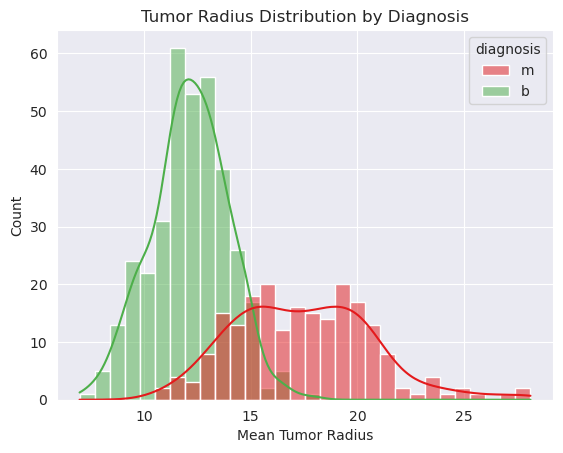

In [25]:
sns.histplot(
    data=wis,
    x='radius_mean',
    hue='diagnosis',
    kde=True,
    bins=30,
    palette={'m': '#e41a1c', 'b': '#4daf4a'}
)

plt.xlabel("Mean Tumor Radius")
plt.ylabel("Count")
plt.title("Tumor Radius Distribution by Diagnosis")
plt.show()

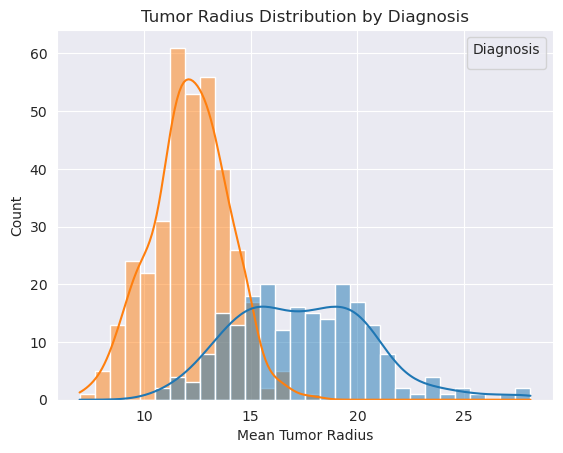

In [26]:
sns.histplot(data=wis, x='radius_mean', hue='diagnosis', kde=True, bins=30)

plt.xlabel("Mean Tumor Radius")
plt.ylabel("Count")
plt.title("Tumor Radius Distribution by Diagnosis")
plt.legend(title='Diagnosis')
plt.show()

### How do key metabolic markers compare between cancer patients and healthy controls?

**First, subset to only the Coimbra dataset rows (which contain metabolic data):**

In [27]:
coimbra = combined[combined['dataset'] == 'coimbra'].copy()
coimbra['classification'].value_counts()

classification
cancer     64
healthy    52
Name: count, dtype: int64

**Calculate summary statistics for glucose and BMI by classification:**

In [28]:
coimbra.groupby('classification')[['glucose', 'bmi', 'insulin']].describe()

glucose                                                    \
                 count        mean        std   min    25%   50%     75%   
classification                                                             
cancer            64.0  105.562500  26.557440  70.0  92.00  98.5  109.00   
healthy           52.0   88.230769  10.191529  60.0  82.75  87.0   93.25   

                        bmi                                                    \
                  max count       mean       std    min        25%        50%   
classification                                                                  
cancer          201.0  64.0  26.984740  4.620398  18.37  22.788722  27.408027   
healthy         118.0  52.0  28.317336  5.427465  18.67  23.096003  27.694389   

                                     insulin                               \
                      75%        max   count       mean        std    min   
classification                                                              
cancer          30.810069  37.109375    64.0  12.513219  12.317738  2.432   
healthy         32.328091  38.578759    52.0   6.933769   4.859793  2.707   

                                               
                  25%     50%     75%     max  
classification                                 
cancer          4.406  7.5800  16.063  58.460  
healthy         4.304  5.4835   7.001  26.211

**Create boxplots of glucose, BMI, and insulin by classification:**

Across all three metabolic markers, cancer patients show higher median values and greater spread than healthy controls. Glucose shows the most pronounced separation, suggesting that elevated blood glucose is more strongly associated with a cancer diagnosis than BMI or insulin alone.

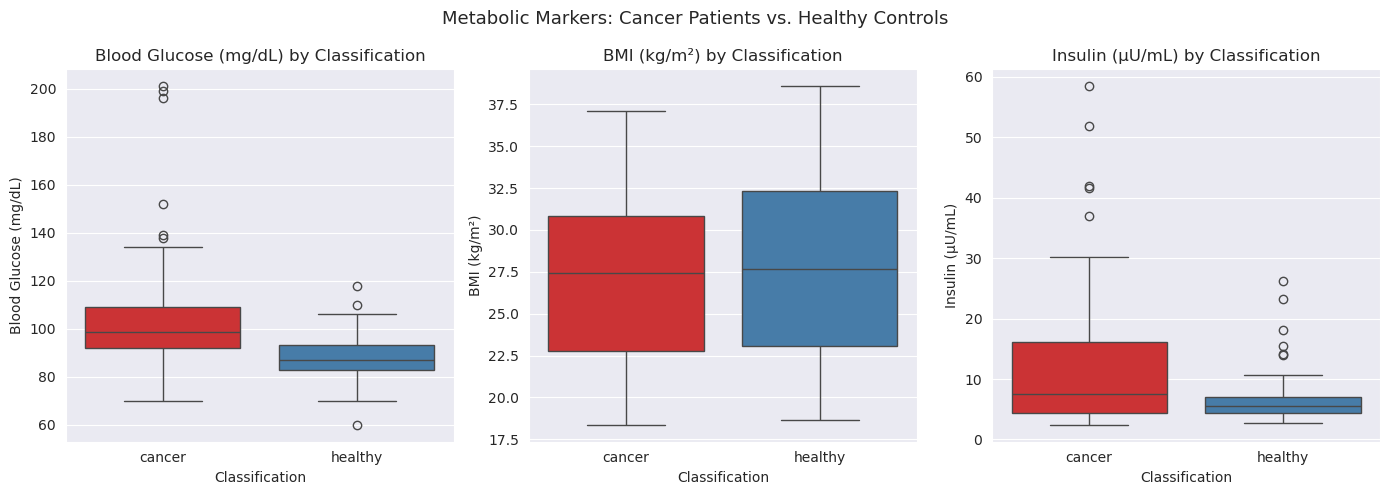

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, col, label in zip(axes,
                           ['glucose', 'bmi', 'insulin'],
                           ['Blood Glucose (mg/dL)', 'BMI (kg/m²)', 'Insulin (µU/mL)']):
    sns.boxplot(data=coimbra, x='classification', y=col, ax=ax, palette='Set1')
    ax.set_title(f'{label} by Classification')
    ax.set_xlabel('Classification')
    ax.set_ylabel(label)

plt.suptitle("Metabolic Markers: Cancer Patients vs. Healthy Controls", fontsize=13)
plt.tight_layout()
plt.show()

### How correlated are the tumor morphology features in the Wisconsin dataset?

**Create a correlation heatmap of all Wisconsin numeric features:**

The heatmap reveals strong positive correlations among size-related features — `radius_mean`, `perimeter_mean`, and `area_mean` are nearly perfectly correlated with one another (r > 0.99). This multicollinearity is expected, since these three measurements all describe the physical size of the same tumor. Texture and fractal dimension features show weaker correlations with the size cluster, suggesting they capture independent aspects of tumor morphology.

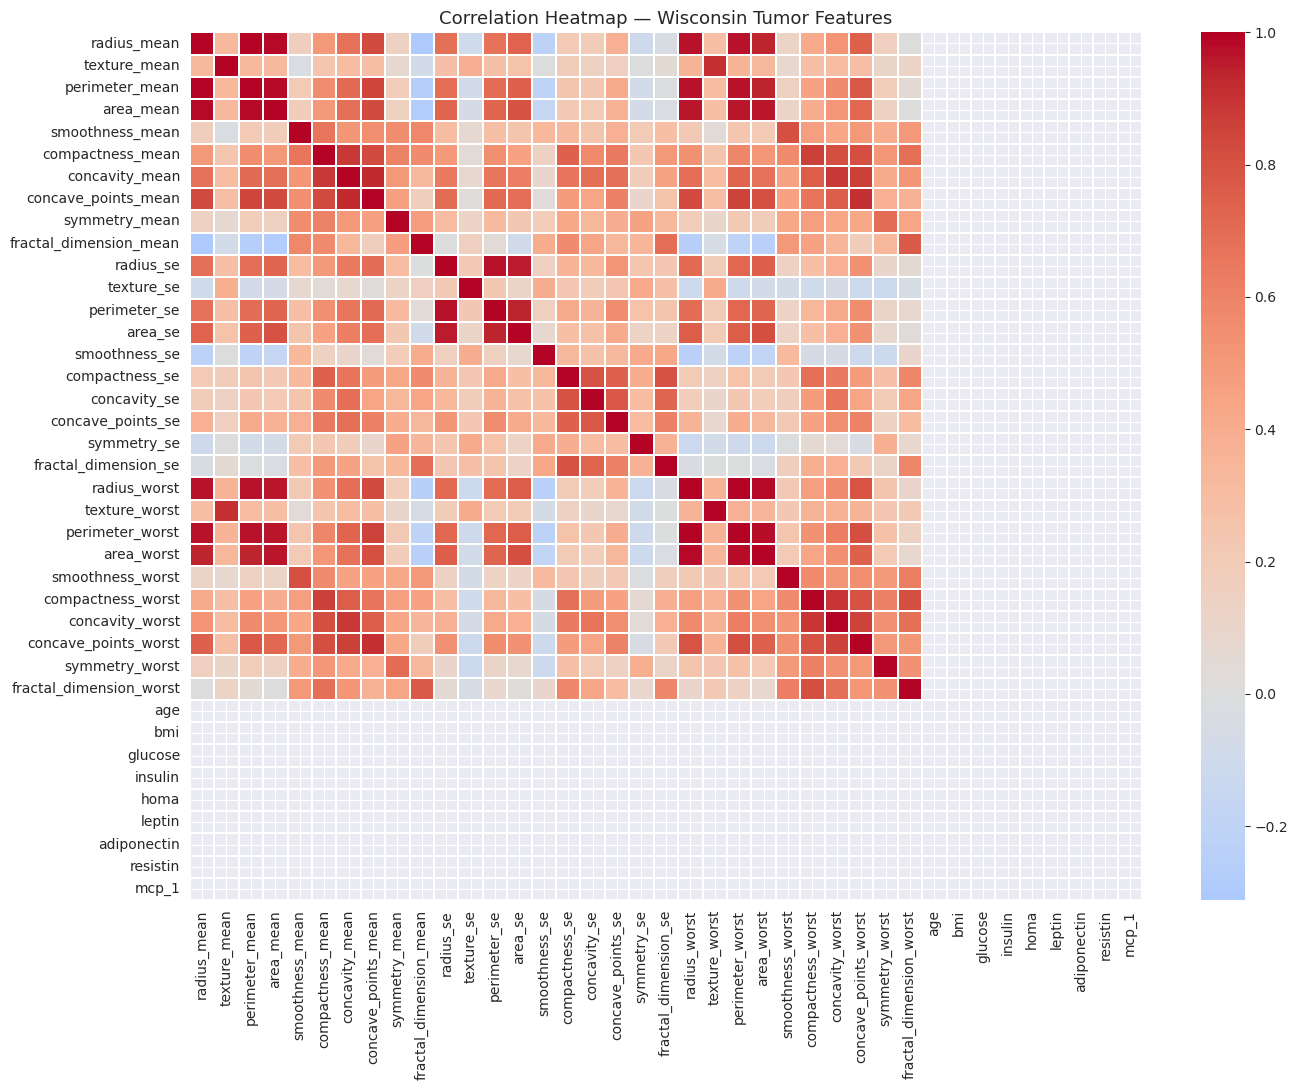

In [30]:
wis_numeric = wis.select_dtypes(include='number').drop(columns=['dataset'], errors='ignore')

plt.figure(figsize=(14, 11))
sns.heatmap(wis_numeric.corr(), cmap='coolwarm', center=0,
            linewidths=0.3, annot=False)
plt.title("Correlation Heatmap — Wisconsin Tumor Features", fontsize=13)
plt.tight_layout()
plt.show()

### How does the distribution of key tumor features differ by diagnosis?

**Create a faceted violin plot showing the distribution of area, concavity, and symmetry by diagnosis:**

Malignant tumors have substantially larger area and greater concavity compared to benign tumors, and the distributions for these features show clear separation. Symmetry, by contrast, shows less separation — the overlap between malignant and benign distributions is much greater — suggesting it is a weaker discriminating feature on its own.

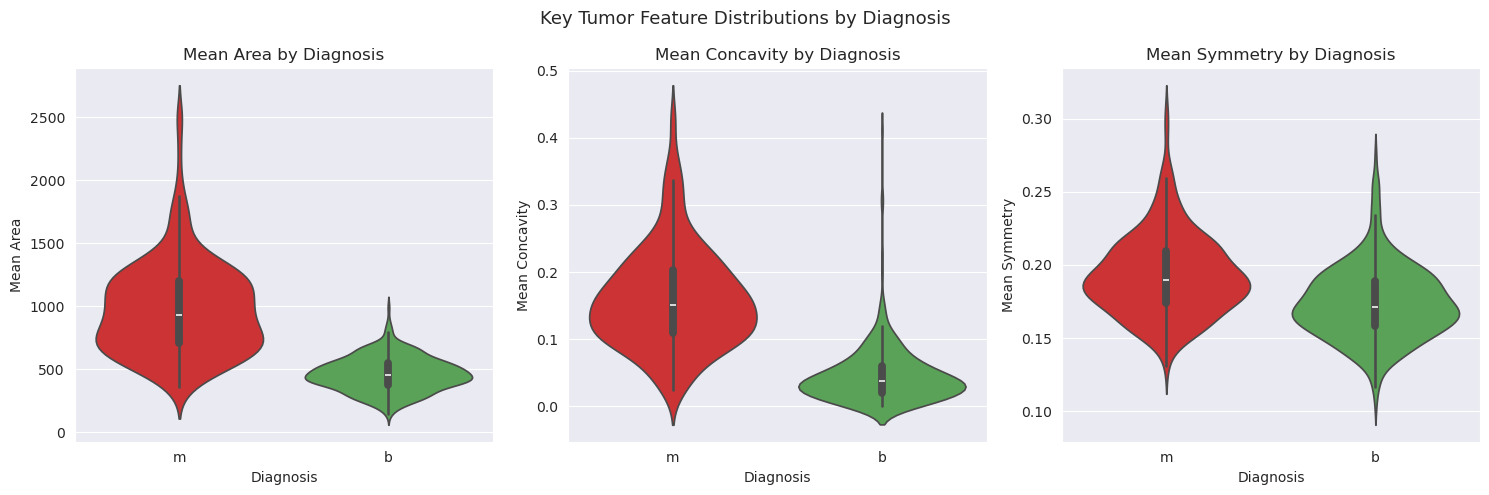

In [31]:
features = ['area_mean', 'concavity_mean', 'symmetry_mean']
labels   = ['Mean Area', 'Mean Concavity', 'Mean Symmetry']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, feat, label in zip(axes, features, labels):
    sns.violinplot(data=wis, x='diagnosis', y=feat, ax=ax,
                   palette={'b': '#4daf4a', 'm': '#e41a1c'})
    ax.set_title(f'{label} by Diagnosis')
    ax.set_xlabel('Diagnosis')
    ax.set_ylabel(label)

plt.suptitle("Key Tumor Feature Distributions by Diagnosis", fontsize=13)
plt.tight_layout()
plt.show()

### What is the average value of each metabolic marker for cancer patients vs. healthy controls?

**Calculate mean values for all metabolic markers by classification:**

In [32]:
metabolic_cols = ['glucose', 'bmi', 'insulin', 'homa', 'leptin', 'adiponectin', 'resistin', 'mcp_1']
grouped = coimbra.groupby('classification')[metabolic_cols].mean().reset_index()
print(grouped)

  classification     glucose        bmi    insulin      homa     leptin  \
0         cancer  105.562500  26.984740  12.513219  3.623342  26.596512   
1        healthy   88.230769  28.317336   6.933769  1.552398  26.637933   

   adiponectin   resistin       mcp_1  
0    10.061167  17.253777  563.016500  
1    10.328205  11.614813  499.730692  


**Reformat for visualization:**

In [33]:
grouped_melted = grouped.melt(id_vars='classification',
                              value_vars=metabolic_cols,
                              var_name='Marker',
                              value_name='Mean Value')
grouped_melted.head()

,classification,Marker,Mean Value
0,cancer,glucose,105.562500
1,healthy,glucose,88.230769
2,cancer,bmi,26.984740
3,healthy,bmi,28.317336
4,cancer,insulin,12.513219


**Create a grouped bar chart of mean metabolic marker values by classification:**

Cancer patients show elevated mean values for glucose, insulin, HOMA (insulin resistance index), resistin, and MCP-1 compared to healthy controls. Adiponectin is notably lower in cancer patients, which aligns with existing clinical literature suggesting that adiponectin has a protective effect against cancer. Leptin and BMI show more modest differences between groups.

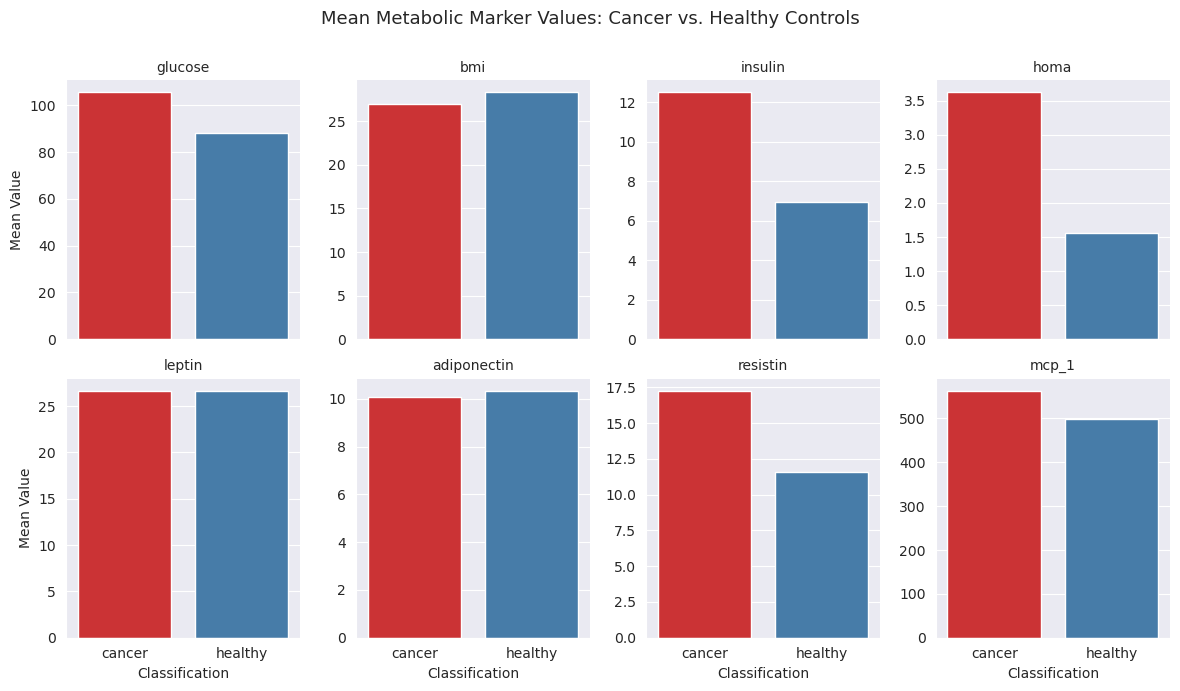

In [34]:
g = sns.catplot(data=grouped_melted, x='classification', y='Mean Value',
               col='Marker', col_wrap=4, kind='bar',
               height=3.5, aspect=0.85, palette='Set1', sharey=False)

g.fig.subplots_adjust(top=0.88)
g.fig.suptitle("Mean Metabolic Marker Values: Cancer vs. Healthy Controls", fontsize=13)
g.set_axis_labels("Classification", "Mean Value")
g.set_titles(col_template="{col_name}")
plt.show()

### Feature Engineering: Risk Level and BMI-Age Ratio

Two new columns are added to the Coimbra dataset to support further analysis:

- **`risk_level`** (categorical): classifies each patient as `"high"` or `"low"` risk based on whether their blood glucose level exceeds the dataset median. Elevated glucose is associated with higher cancer risk, so this threshold-based split provides a clinically motivated binary grouping.
- **`bmi_age_ratio`** (numeric): computes BMI divided by age. This ratio captures whether a patient's body mass is high relative to their age, since the relationship between BMI and cancer risk may differ across age groups.

In [35]:
glucose_median = coimbra['glucose'].median()
coimbra['risk_level'] = np.where(coimbra['glucose'] > glucose_median, 'high', 'low')

coimbra['bmi_age_ratio'] = coimbra['bmi'] / coimbra['age']

coimbra[['classification', 'glucose', 'risk_level', 'bmi', 'age', 'bmi_age_ratio']].head(10)

,classification,glucose,risk_level,bmi,age,bmi_age_ratio
569,healthy,70.0,low,23.500000,48.0,0.489583
570,healthy,92.0,low,20.690495,83.0,0.249283
571,healthy,91.0,low,23.124670,82.0,0.282008
572,healthy,77.0,low,21.367521,68.0,0.314228
573,healthy,92.0,low,21.111111,86.0,0.245478
574,healthy,92.0,low,22.854458,49.0,0.466418
575,healthy,77.0,low,22.700000,89.0,0.255056
576,healthy,118.0,high,23.800000,76.0,0.313158
577,healthy,97.0,high,22.000000,73.0,0.301370
578,healthy,83.0,low,23.000000,75.0,0.306667


**How does risk level map onto the actual classification labels?**

If elevated glucose is genuinely predictive, we would expect a higher proportion of cancer patients in the `high` risk group.

In [36]:
risk_crosstab = pd.crosstab(coimbra['risk_level'], coimbra['classification'], normalize='index') * 100
print("Row-normalized percentages (%):")
print(risk_crosstab.round(1))

Row-normalized percentages (%):
classification  cancer  healthy
risk_level                     
high              75.4     24.6
low               35.6     64.4


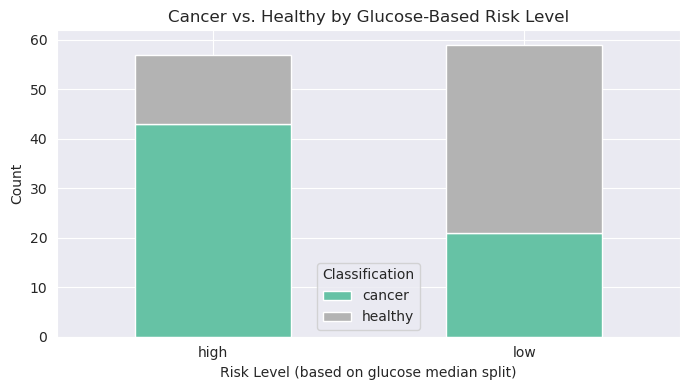

In [37]:
risk_counts = pd.crosstab(coimbra['risk_level'], coimbra['classification'])

risk_counts.plot(kind='bar', stacked=True, colormap='Set2', figsize=(7, 4))
plt.title("Cancer vs. Healthy by Glucose-Based Risk Level")
plt.xlabel("Risk Level (based on glucose median split)")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.legend(title='Classification')
plt.tight_layout()
plt.show()

**How does BMI-Age ratio compare between cancer patients and healthy controls?**

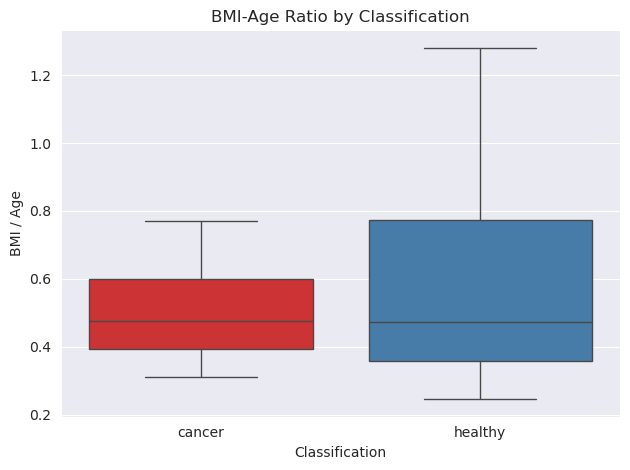

In [38]:
sns.boxplot(data=coimbra, x='classification', y='bmi_age_ratio', palette='Set1')
plt.title("BMI-Age Ratio by Classification")
plt.xlabel("Classification")
plt.ylabel("BMI / Age")
plt.tight_layout()
plt.show()

### How do the most discriminating Wisconsin features relate to one another across diagnoses?

**Create a pair plot for the top discriminating tumor features:**

The pair plot confirms that the strongest separation between malignant and benign tumors occurs along the size-related axes (`area_mean`, `radius_mean`, `concavity_mean`). Benign tumors cluster tightly in the lower-left of each size-vs-size scatter, while malignant tumors are spread over a broader range of larger values. Symmetry continues to show substantial overlap between the two classes.

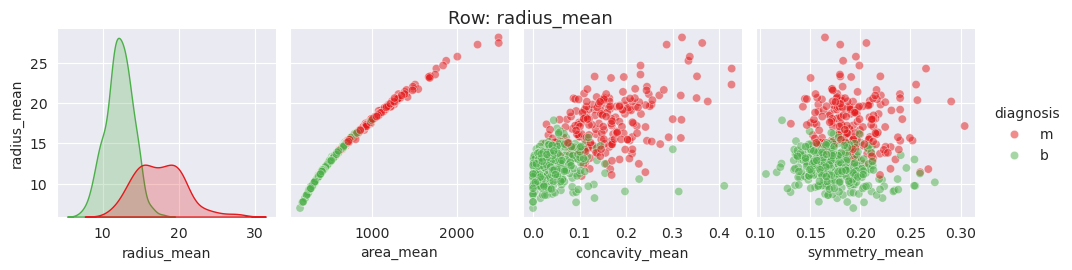

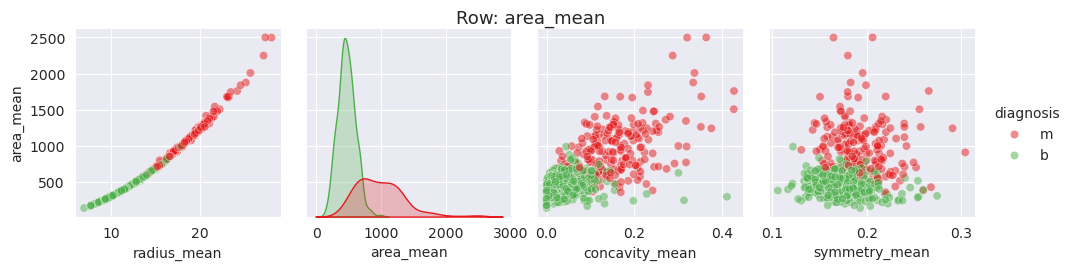

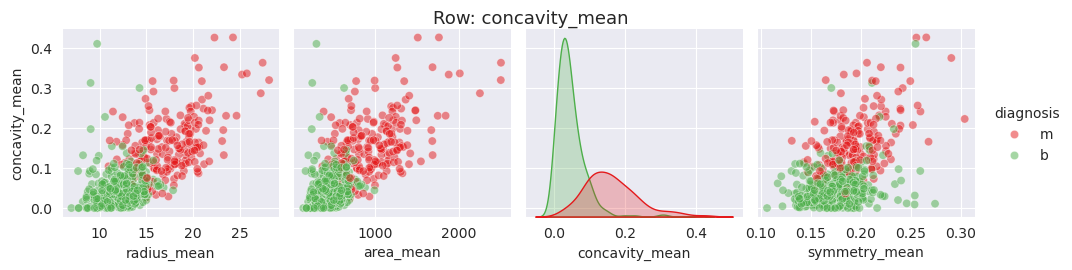

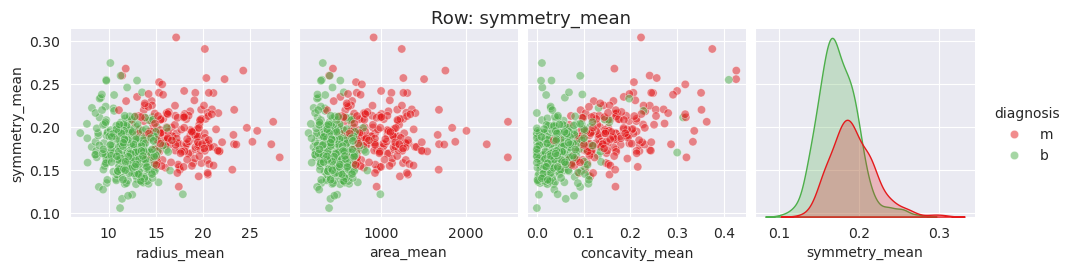

In [39]:
top_features = ['radius_mean', 'area_mean', 'concavity_mean', 'symmetry_mean']

for row_feat in top_features:
    plot_features = top_features.copy()
    g = sns.pairplot(wis[plot_features + ['diagnosis']], hue='diagnosis',
                     palette={'b': '#4daf4a', 'm': '#e41a1c'},
                     plot_kws={'alpha': 0.5}, diag_kind='kde',
                     y_vars=[row_feat], x_vars=plot_features)

    g.fig.suptitle(f'Row: {row_feat}', y=1.04, fontsize=13)
    plt.show()

## **Summary:**

To better understand what measurable features are most associated with breast cancer diagnosis, we analyzed two publicly available datasets: the Wisconsin Breast Cancer Dataset (tumor morphology features from 569 patients) and the Breast Cancer Coimbra Dataset (metabolic and demographic markers from 116 patients and controls). The methodology included descriptive statistics, data visualization, feature engineering, and grouped analysis.

### Interesting Insights:

#### Tumor Morphology (Wisconsin Dataset):
- Tumor size features — specifically `radius_mean`, `perimeter_mean`, and `area_mean` — are the strongest discriminators between malignant and benign tumors. Malignant tumors have substantially larger mean radii and areas, with relatively little distributional overlap.
- Concavity is another strong discriminating feature: malignant tumors show markedly greater mean concavity than benign tumors, reflecting the more irregular shape typical of cancerous growths.
- Size-related features are nearly perfectly correlated with one another (r > 0.99), indicating high multicollinearity. Any future predictive model should use dimensionality reduction (e.g., PCA) or feature selection to avoid overfitting.
- Symmetry shows the least separation between diagnostic classes and is likely the weakest morphological predictor on its own.

#### Metabolic Markers (Coimbra Dataset):
- Cancer patients show higher mean glucose, insulin, HOMA (insulin resistance), resistin, and MCP-1 values compared to healthy controls. These differences are consistent with existing clinical literature linking metabolic syndrome to increased cancer risk.
- Adiponectin is notably *lower* in cancer patients than in healthy controls — supporting published findings that adiponectin has a protective, anti-inflammatory role against breast cancer.
- A glucose-based binary risk split (above vs. below the dataset median) correctly identifies a higher proportion of cancer patients in the "high risk" group, suggesting that glucose alone captures meaningful signal.

### Analysis Limitations and Areas for Potential Improvement:

- The two datasets measure entirely different features and were collected in different countries and time periods, which limits the ability to draw integrated conclusions about tumor characteristics *and* metabolic health in the same patient.
- The Coimbra dataset is small (116 observations), which reduces the statistical power of subgroup comparisons and makes it difficult to distinguish true signal from noise.
- Neither dataset contains longitudinal information, so it is not possible to determine whether elevated metabolic markers preceded or followed the cancer diagnosis.
- Future work should attempt to find or collect a single dataset that combines both tumor morphology and metabolic markers for the same patients, enabling a multivariate model that integrates both feature types for improved predictive accuracy.